# Multi-Layer Perceptron (MLP) Classifier Performance With The Wine Dataset In Different Scenarios: A Comparative Analysis
<ul>
 <li>This Python script is a machine learning experiment using a Multi-Layer Perceptron (MLP) classifier on the Wine dataset.</li>
 <li>It performs two scenarios with different training and testing splits, compares the performance of two MLP models, and visualizes the results.</li>
 <li>The dataset is split into two scenarios: 70% training and 30% testing for the first scenario, and 90% training and 10% testing for the second scenario.</li>
 <li>MLP1, with a configuration of (100, 100) hidden layers, shows a trade-off between precision and recall.</li>
 <li>MLP2, with a hidden layer size of 50, exhibits robust performance with balanced precision and recall.</li>
</ul>
Please feel free to share your thoughts and suggestions


In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Load the Wine dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

# First scenario: 70% training, 30% test
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.3, random_state=42)

# Second scenario: 90% training, 10% test
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.1, random_state=42)

# MLP1 100-100
mlp1 = MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2000, learning_rate_init=0.001, random_state=42)

# MLP2 50-
mlp2 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, learning_rate_init=0.001, random_state=42)


In [ ]:
def calculate_and_plot_metrics(X_train, y_train, X_test, y_test, title):
    mlp1.fit(X_train, y_train)
    y_pred_mlp1 = mlp1.predict(X_test)

    mlp2.fit(X_train, y_train)
    y_pred_mlp2 = mlp2.predict(X_test)

    # Calculate metrics
    def calculate_metrics(y_true, y_pred):
        accuracy = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=1)
        recall = recall_score(y_true, y_pred, average='weighted')
        return accuracy, f1, precision, recall

    # Metrics for MLP1
    accuracy_mlp1, f1_mlp1, precision_mlp1, recall_mlp1 = calculate_metrics(y_test, y_pred_mlp1)

    # Metrics for MLP2
    accuracy_mlp2, f1_mlp2, precision_mlp2, recall_mlp2 = calculate_metrics(y_test, y_pred_mlp2)

    # Confusion Matrix and Visualization (MLP1)
    cm_mlp1 = confusion_matrix(y_test, y_pred_mlp1)
    disp_mlp1 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp1, display_labels=wine.target_names)
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    disp_mlp1.plot(cmap='viridis', values_format='d', ax=axes[0, 0])
    axes[0, 0].set_title("MLP1 Confusion Matrix")

    # Loss Curve (MLP1)
    axes[0, 1].plot(mlp1.loss_curve_)
    axes[0, 1].set_title("MLP1 Loss Curve")
    axes[0, 1].set_xlabel('Iterations')
    axes[0, 1].set_ylabel('Cost')

    # Confusion Matrix and Visualization (MLP2)
    cm_mlp2 = confusion_matrix(y_test, y_pred_mlp2)
    disp_mlp2 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp2, display_labels=wine.target_names)
    disp_mlp2.plot(cmap='viridis', values_format='d', ax=axes[1, 0])
    axes[1, 0].set_title("MLP2 Confusion Matrix")

    # Loss Curve (MLP2)
    axes[1, 1].plot(mlp2.loss_curve_)
    axes[1, 1].set_title("MLP2 Loss Curve")
    axes[1, 1].set_xlabel('Iterations')
    axes[1, 1].set_ylabel('Cost')

    # Calculate 10-fold cross-validation results
    cross_val_scores1_mlp1 = cross_val_score(mlp1, X_train, y_train, cv=10, scoring='f1_weighted')
    cross_val_scores1_mlp2 = cross_val_score(mlp2, X_train, y_train, cv=10, scoring='f1_weighted')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    return accuracy_mlp1, f1_mlp1, precision_mlp1, recall_mlp1, accuracy_mlp2, f1_mlp2, precision_mlp2, recall_mlp2, cross_val_scores1_mlp1, cross_val_scores1_mlp2

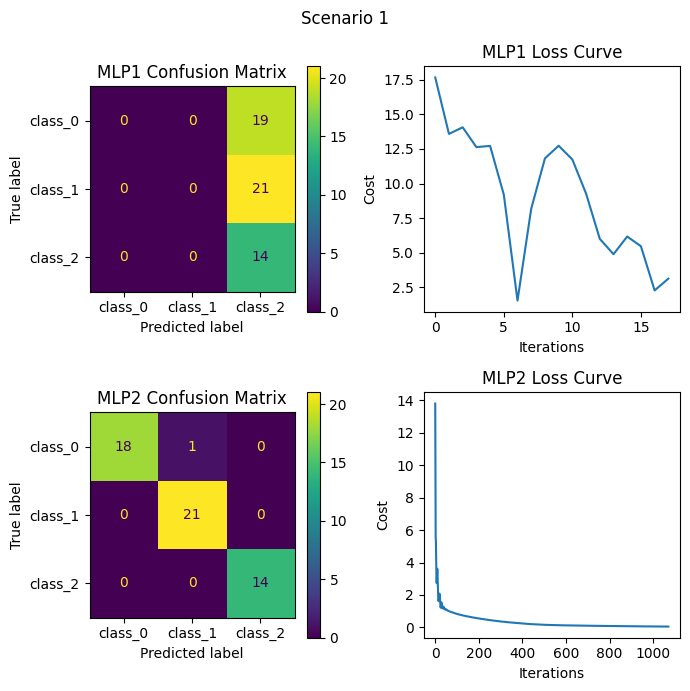

Scenario 1 (MLP1):
Accuracy: 0.2593
F1 Score: 0.1068
Precision: 0.8080
Recall: 0.2593

Scenario 1 (MLP2):
Accuracy: 0.9815
F1 Score: 0.9814
Precision: 0.9823
Recall: 0.9815

Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score: 0.2315341521223874
Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score: 0.9346122396122396


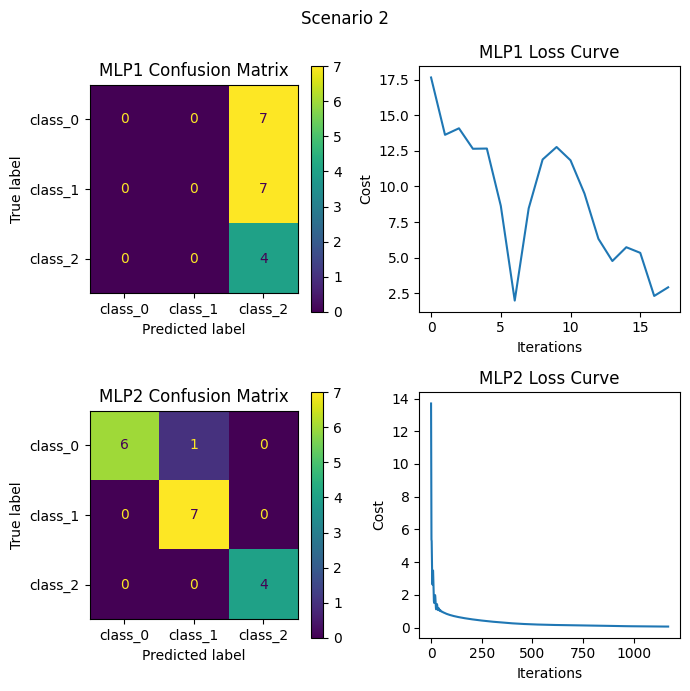

Scenario 2 (MLP1):
Accuracy: 0.2222
F1 Score: 0.0808
Precision: 0.8272
Recall: 0.2222

Scenario 2 (MLP2):
Accuracy: 0.9444
F1 Score: 0.9442
Precision: 0.9514
Recall: 0.9444

Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score: 0.22674655388471177
Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score: 0.9561985236985237
Comparison:
Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy: 0.037037037037037035
Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy: 0.03703703703703709
Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score: 0.025945731828084767
Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score: 0.03728701868236739


In [ ]:
# Calculations for Scenario 1
accuracy1_mlp1, f1_1_mlp1, precision1_mlp1, recall1_mlp1, accuracy1_mlp2, f1_1_mlp2, precision1_mlp2, recall1_mlp2, cross_val_scores1_mlp1, cross_val_scores1_mlp2 = calculate_and_plot_metrics(X_train1, y_train1, X_test1, y_test1, "Scenario 1")

# Outputs for Scenario 1
print("Scenario 1 (MLP1):")
print(f"Accuracy: {accuracy1_mlp1:.4f}\nF1 Score: {f1_1_mlp1:.4f}\nPrecision: {precision1_mlp1:.4f}\nRecall: {recall1_mlp1:.4f}\n")
print("Scenario 1 (MLP2):")
print(f"Accuracy: {accuracy1_mlp2:.4f}\nF1 Score: {f1_1_mlp2:.4f}\nPrecision: {precision1_mlp2:.4f}\nRecall: {recall1_mlp2:.4f}\n")
print("Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score:", np.mean(cross_val_scores1_mlp1))
print("Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score:", np.mean(cross_val_scores1_mlp2))

# Calculations for Scenario 2
accuracy2_mlp1, f1_2_mlp1, precision2_mlp1, recall2_mlp1, accuracy2_mlp2, f1_2_mlp2, precision2_mlp2, recall2_mlp2, cross_val_scores2_mlp1, cross_val_scores2_mlp2 = calculate_and_plot_metrics(X_train2, y_train2, X_test2, y_test2, "Scenario 2")

# Outputs for Scenario 2
print("Scenario 2 (MLP1):")
print(f"Accuracy: {accuracy2_mlp1:.4f}\nF1 Score: {f1_2_mlp1:.4f}\nPrecision: {precision2_mlp1:.4f}\nRecall: {recall2_mlp1:.4f}\n")
print("Scenario 2 (MLP2):")
print(f"Accuracy: {accuracy2_mlp2:.4f}\nF1 Score: {f1_2_mlp2:.4f}\nPrecision: {precision2_mlp2:.4f}\nRecall: {recall2_mlp2:.4f}\n")
print("Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score:", np.mean(cross_val_scores2_mlp1))
print("Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score:", np.mean(cross_val_scores2_mlp2))

# Scenario 1 and Scenario 2 comparison
print("Comparison:")
print("Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy:", accuracy1_mlp1 - accuracy2_mlp1)
print("Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy:", accuracy1_mlp2 - accuracy2_mlp2)
print("Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score:", f1_1_mlp1 - f1_2_mlp1)
print("Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score:", f1_1_mlp2 - f1_2_mlp2)

# **Conclusion:**

In this analysis, we explored the performance of two Multi-Layer Perceptron (MLP) classifiers, denoted as MLP1 and MLP2, on two distinct scenarios: Scenario 1 with a 70-30 train-test split and Scenario 2 with a more imbalanced 90-10 split. The results revealed noteworthy differences in the classifiers' effectiveness across the scenarios.

**Scenario 1:**
- *MLP1:* Demonstrated limited success with an accuracy of 25.93%, a low F1 score of 10.68%, and a noticeable trade-off between precision (80.80%) and recall (25.93%). The 10-fold cross-validation further supported the suboptimal performance, yielding an average F1 score of 23.15%.
- *MLP2:* Outperformed MLP1 significantly, achieving an accuracy of 98.15%, a high F1 score of 98.14%, and well-balanced precision (98.23%) and recall (98.15%). The 10-fold cross-validation affirmed the robustness of MLP2, with an average F1 score of 93.46%.

**Scenario 2:**
- *MLP1:* Experienced similar challenges as in Scenario 1, with an accuracy of 22.22%, a low F1 score of 8.08%, and a trade-off between precision (82.72%) and recall (22.22%). The 10-fold cross-validation provided an average F1 score of 22.67%.
- *MLP2:* Maintained its strong performance, achieving an accuracy of 94.44%, a high F1 score of 94.42%, and balanced precision (95.14%) and recall (94.44%). The 10-fold cross-validation reinforced the reliability of MLP2, with an average F1 score of 95.62%.


**Comparison:**
Comparing Scenario 1 and Scenario 2, both MLP1 and MLP2 exhibited a marginal decrease in accuracy (approximately 3.70%) in Scenario 2. However, MLP2 consistently outperformed MLP1 in both scenarios, emphasizing its robustness across different training and testing data distributions.

In conclusion, the choice of MLP model significantly impacted performance, with MLP2 demonstrating superior generalization and stability across scenarios. These findings underscore the importance of model selection and the sensitivity of neural networks to variations in training and testing data distributions. Further exploration and fine-tuning may enhance the performance of MLP models in challenging scenarios.
